In [3]:
# =============================================
# STEP 1 (updated) — Expanded unified feature matrix
# =============================================

import json
import pandas as pd

def bool_to_int(v):
    if isinstance(v, bool):
        return int(v)
    if isinstance(v, (int, float)):
        return int(v != 0)
    if isinstance(v, str):
        return int(v.strip().lower() in ["1","true","yes","y"])
    return 0

with open("../Features/OUTPUT_JSON_HEART.json","r",encoding="utf-8") as f:
    heart = json.load(f)
with open("../Features/OUTPUT_JSON_MICROBIOLOGY.json","r",encoding="utf-8") as f:
    micro = json.load(f)

rows = []
all_ids = set(heart['subjects'].keys()) | set(micro['subjects'].keys())

for sid in all_ids:
    hd = heart['subjects'].get(sid, {}).get("heart_dataset", {})
    md = micro['subjects'].get(sid, {}).get("microbiology_dataset", {})
    bf = hd.get("binary_findings_summary", {})
    vs = hd.get("vitals_summary", {})
    cat = hd.get("categorical_summary", {})

    row = {"subject_id": sid}

    # --- Demographics ---
    row["age"] = hd.get("age", 0) or 0
    gen = hd.get("gender", None)
    row["gender_M"] = 1 if str(gen).upper().startswith("M") else 0
    row["gender_F"] = 1 if str(gen).upper().startswith("F") else 0

    # --- Cardiac record counts ---
    row["heart_n_records"] = hd.get("n_records", 0)
    row["heart_unique_admissions"] = hd.get("unique_admission_count", 0)
    row["heart_unique_dx_codes"] = len(hd.get("unique_diagnosis_codes", []))

    # --- Heart binary findings ---
    heart_keys = [
        "atrial_fibrillation_ever","lv_dilated_ever","pulmonary_hypertension_ever",
        "mitral_regurgitation_ever","pleural_effusion_ever","pulmonary_edema_ever",
        "aortic_stenosis_ever","pericardial_effusion_ever","lvh_ever","wall_motion_abnormality_ever",
        "st_elevation_ever","st_depression_ever","q_waves_ever","lbbb_ever","rbbb_ever",
        "cabg_ever","stent_placed_ever","coronary_artery_disease_ever","aortic_aneurysm_ever",
        "aortic_dissection_ever","coronary_calcification_ever","crackles_present_ever",
        "edema_present_ever","murmur_present_ever","nad_ever","perrl_ever"
    ]
    for k in heart_keys:
        row[k] = bool_to_int(bf.get(k, False))

    # --- Vital‑sign means ---
    for v in ["temperature","bp_systolic","bp_diastolic","heart_rate",
              "respiratory_rate","oxygen_saturation"]:
        row[v+"_mean"] = vs.get(v+"_summary", {}).get("mean", 0.0) or 0.0

    # --- Cardiac categorical encodings ---
    risk = cat.get("risk_category_mode")
    row["risk_category"] = {"Low":0,"Medium":1,"High":2}.get(risk,0)
    rhythm = cat.get("rhythm_mode")
    row["rhythm_afib"] = 1 if rhythm == "atrial_fibrillation" else 0

    # --- Microbiology aggregates ---
    row["micro_n_records"] = md.get("n_records", 0)
    row["micro_unique_admissions"] = md.get("unique_admission_count", 0)
    row["n_ab_tests"] = md.get("n_ab_tests", 0)
    row["num_unique_spec_types"] = len(md.get("unique_spec_types", []))
    row["num_unique_tests"] = len(md.get("unique_tests", []))
    row["num_unique_organisms"] = len(md.get("unique_organisms", []))
    row["num_unique_antibiotics"] = len(md.get("unique_antibiotics", []))
    row["num_anatomical_sites"] = len(md.get("anatomical_site", []))
    row["num_sample_formats"] = len(md.get("sample_format", []))
    row["num_test_modalities"] = len(md.get("test_modality", []))
    row["num_target_classes"] = len(md.get("target_organism_class", []))
    row["num_purpose_types"] = len(md.get("purpose_specific", []))

    rsi = md.get("rsi_counts_and_ratios_qc_ok_&_warn", {})
    row["r_count"] = rsi.get("R", 0) or 0
    row["s_count"] = rsi.get("S", 0) or 0
    row["i_count"] = rsi.get("I", 0) or 0
    row["S_over_total_rsi"] = rsi.get("S_over_total_rsi", 0) or 0
    row["S_I_over_total_rsi"] = rsi.get("S_&_I_over_total_rsi", 0) or 0

    # diversity ratios
    tot = row["micro_n_records"] or 1
    row["ab_test_ratio"] = row["n_ab_tests"]/tot
    row["site_diversity_index"] = row["num_anatomical_sites"]/tot
    row["organism_diversity_index"] = row["num_unique_organisms"]/tot

    rows.append(row)

df_features = pd.DataFrame(rows).fillna(0)
print("Unified DataFrame shape:", df_features.shape)
df_features.head()

Unified DataFrame shape: (4576, 61)


,subject_id,age,gender_M,gender_F,heart_n_records,heart_unique_admissions,heart_unique_dx_codes,atrial_fibrillation_ever,lv_dilated_ever,pulmonary_hypertension_ever,...,num_target_classes,num_purpose_types,r_count,s_count,i_count,S_over_total_rsi,S_I_over_total_rsi,ab_test_ratio,site_diversity_index,organism_diversity_index
0,17223869,0,1,0,1,1,1,1,0,0,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000
1,10625068,0,0,0,1,1,1,0,1,0,...,6,1,0,0,0,0.0,0.0,0.0,0.333333,0.333333
2,17416292,0,0,1,1,1,1,0,0,0,...,4,2,0,0,0,0.0,0.0,0.0,0.600000,0.200000
3,16580488,0,0,0,1,1,1,0,1,0,...,2,2,0,0,0,0.0,0.0,0.0,0.428571,0.142857
4,19856081,0,0,0,1,1,1,1,1,1,...,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000


In [4]:
df_features.columns

Index(['subject_id', 'age', 'gender_M', 'gender_F', 'heart_n_records',
       'heart_unique_admissions', 'heart_unique_dx_codes',
       'atrial_fibrillation_ever', 'lv_dilated_ever',
       'pulmonary_hypertension_ever', 'mitral_regurgitation_ever',
       'pleural_effusion_ever', 'pulmonary_edema_ever', 'aortic_stenosis_ever',
       'pericardial_effusion_ever', 'lvh_ever', 'wall_motion_abnormality_ever',
       'st_elevation_ever', 'st_depression_ever', 'q_waves_ever', 'lbbb_ever',
       'rbbb_ever', 'cabg_ever', 'stent_placed_ever',
       'coronary_artery_disease_ever', 'aortic_aneurysm_ever',
       'aortic_dissection_ever', 'coronary_calcification_ever',
       'crackles_present_ever', 'edema_present_ever', 'murmur_present_ever',
       'nad_ever', 'perrl_ever', 'temperature_mean', 'bp_systolic_mean',
       'bp_diastolic_mean', 'heart_rate_mean', 'respiratory_rate_mean',
       'oxygen_saturation_mean', 'risk_category', 'rhythm_afib',
       'micro_n_records', 'micro_unique_ad

In [5]:
%pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

Numeric matrix: (4576, 60)


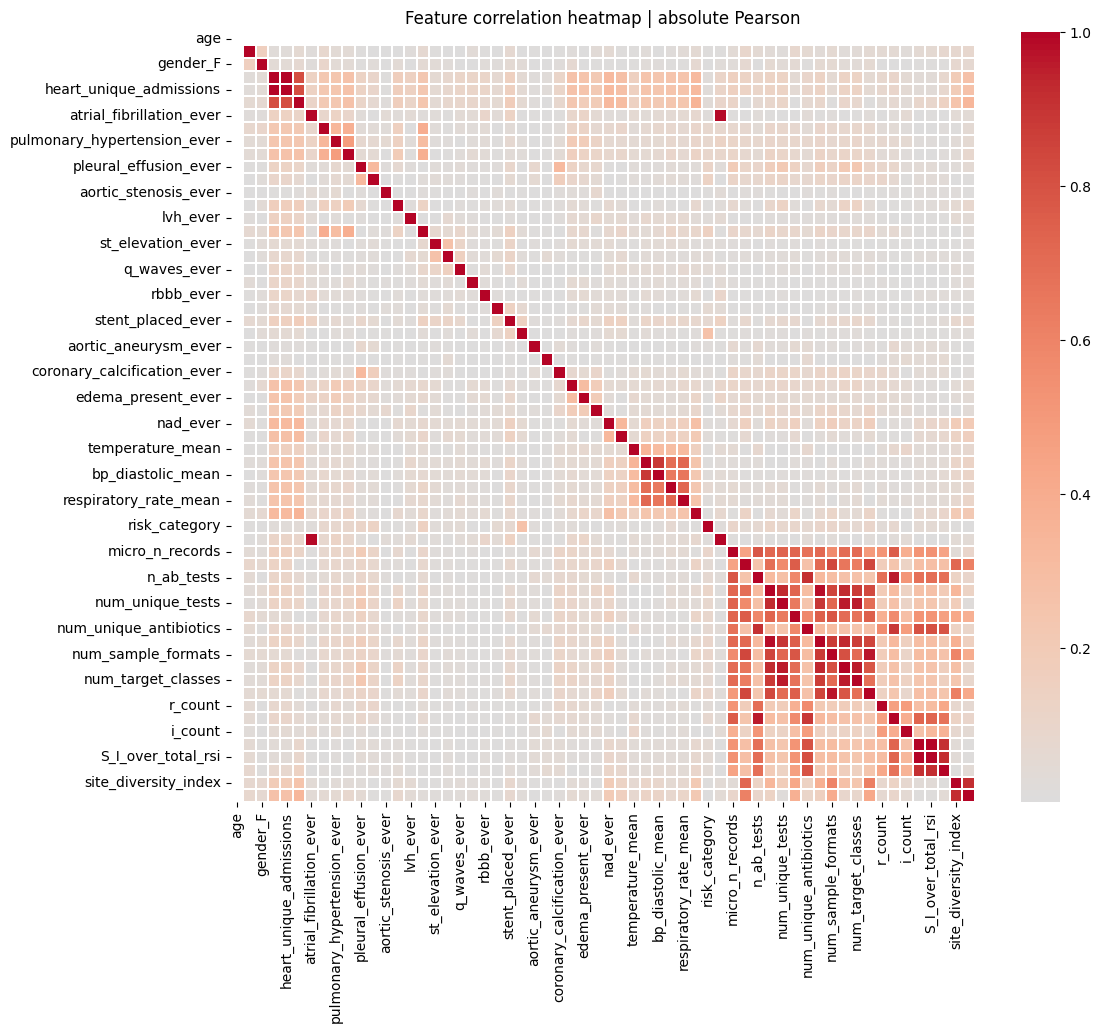

Removing 8 highly correlated columns.
1 columns dropped for zero variance: ['age']
Final feature matrix shape after pruning: (4576, 51)


In [6]:
# =============================================
# STEP 2 — Encode, clean, correlation & variance pruning
# =============================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# 1. Encoding & missing handling (already mostly numeric)
df_clean = df_features.copy()
df_clean = df_clean.fillna(0)

# Remove non‑numeric identifier columns
id_cols = ["subject_id"]
X = df_clean.drop(columns=id_cols)

# Ensure numeric dtype
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Numeric matrix:", X.shape)

# 2. Correlation inspection
corr = X.corr(method='pearson')
plt.figure(figsize=(12,10))
sns.heatmap(corr.abs(), cmap='coolwarm', center=0, linewidths=0.3)
plt.title("Feature correlation heatmap | absolute Pearson")
plt.show()

# Identify highly correlated pairs (>|0.95|)
high_corr = set()
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i,j]) > 0.95:
            col_i = corr.columns[i]
            col_j = corr.columns[j]
            # mark one for removal
            high_corr.add(col_j)
if high_corr:
    print(f"Removing {len(high_corr)} highly correlated columns.")
    X = X.drop(columns=list(high_corr))

# 3. Low‑variance pruning
sel = VarianceThreshold(threshold=0.0)
sel.fit(X)
low_var_cols = X.columns[~sel.get_support()]
print(f"{len(low_var_cols)} columns dropped for zero variance:", list(low_var_cols))
X = X.loc[:, sel.get_support()]

print("Final feature matrix shape after pruning:", X.shape)


# X.to_csv("Unified_Features_Preprocessed.csv", index=False)

Matrix shape for clustering: (4576, 51)


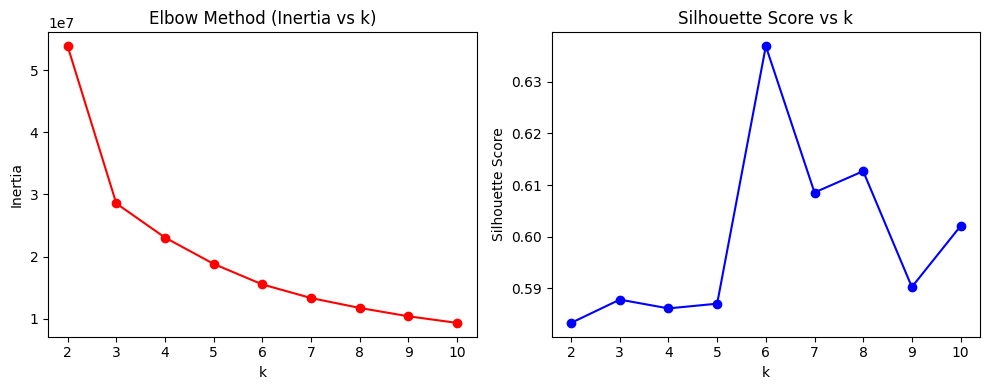

Best k by silhouette: 6

Cluster label distribution:
cluster
0    2181
1    1078
3     818
4     497
2       1
5       1
Name: count, dtype: int64

Silhouette Score: 0.637
Calinski-Harabasz Score: 4406.332


c:\python_ins\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


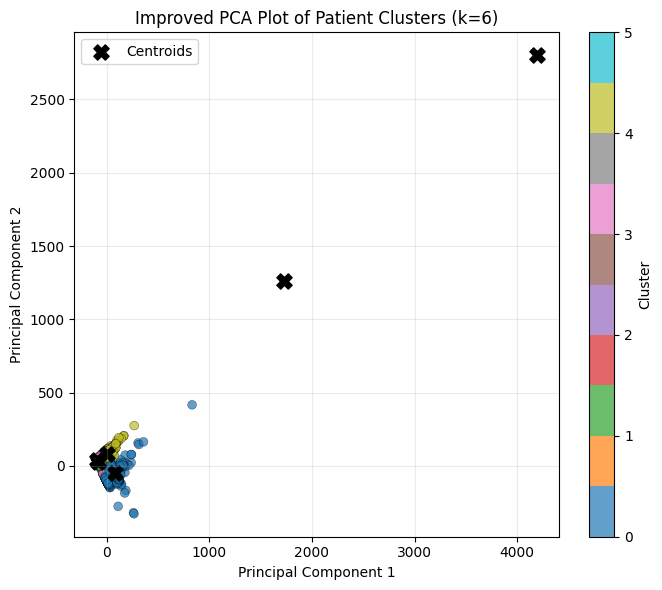

In [7]:
# =============================================
# STEP 3 — K-Means Baseline Clustering
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Assume X is the numeric feature matrix from Step 2
print("Matrix shape for clustering:", X.shape)

# -------- 1. Find optimal number of clusters (elbow + silhouette) --------
inertia = []
silhouette = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(k_values, inertia, 'o-', color='red')
plt.title('Elbow Method (Inertia vs k)')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(k_values, silhouette, 'o-', color='blue')
plt.title('Silhouette Score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Pick best k (max silhouette)
best_k = k_values[int(np.argmax(silhouette))]
print(f"Best k by silhouette: {best_k}")

# -------- 2. Fit final K-Means model --------
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X)

# Attach cluster labels back to the DataFrame
df_clustered = df_clean.copy()
df_clustered['cluster'] = cluster_labels
print("\nCluster label distribution:")
print(df_clustered['cluster'].value_counts())

# -------- 3. Evaluate quality --------
sil_score = silhouette_score(X, cluster_labels)
ch_score = calinski_harabasz_score(X, cluster_labels)

print(f"\nSilhouette Score: {sil_score:.3f}")
print(f"Calinski-Harabasz Score: {ch_score:.3f}")

# -------- 4.1 Improved PCA Visualization --------
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X)

plt.figure(figsize=(7,6))

# Scatter with nicer styling
scatter = plt.scatter(
    reduced[:,0], reduced[:,1],
    c=cluster_labels,
    cmap='tab10',
    s=40,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# Compute and plot centroids in PCA space
centroids = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(
    centroids[:,0], centroids[:,1],
    c='black',
    s=120,
    marker='X',
    label='Centroids'
)

plt.title(f'Improved PCA Plot of Patient Clusters (k={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.25)

# legend
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

plt.legend()
plt.tight_layout()
plt.show()


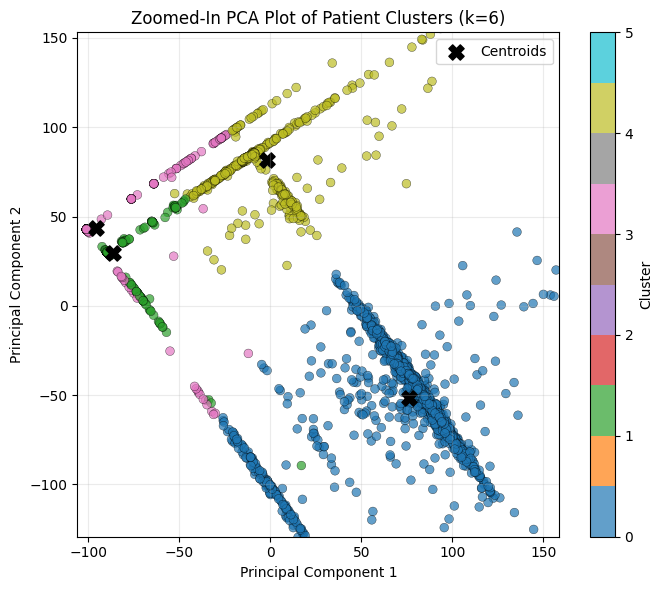

In [8]:
# -------- 4.2 Zoomed-In PCA Plot (Remove Outlier Influence) --------

# Compute percentile limits to trim extreme outliers
x_low, x_high = np.percentile(reduced[:,0], [0.1, 99.5])
y_low, y_high = np.percentile(reduced[:,1], [0.1, 99.5])

plt.figure(figsize=(7,6))

scatter = plt.scatter(
    reduced[:,0], reduced[:,1],
    c=cluster_labels,
    cmap='tab10',
    s=40,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# Plot centroids
plt.scatter(
    centroids[:,0], centroids[:,1],
    c='black',
    s=120,
    marker='X',
    label='Centroids'
)

plt.title(f'Zoomed-In PCA Plot of Patient Clusters (k={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.25)

# Apply zoom limits
plt.xlim(x_low - 5, x_high - 5) # <- Move left | normal plt.xlim(x_low, x_high)
plt.ylim(y_low + 27, y_high + 27) 

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

plt.legend()
plt.tight_layout()
plt.show()


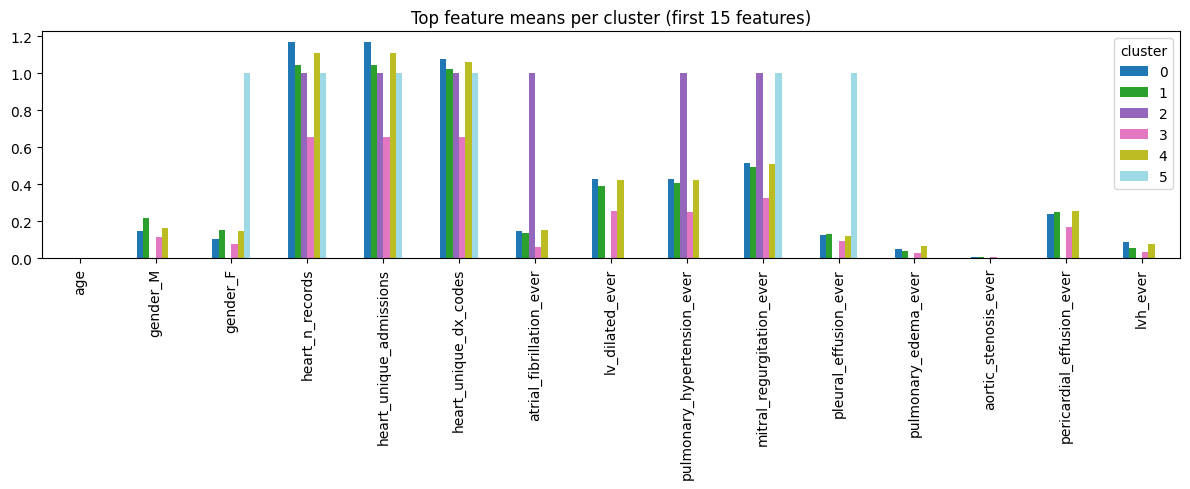

In [9]:
# -------- 5. Cluster summary statistics --------
# Keep only numeric columns to avoid object dtype errors
numeric_cols = df_clustered.select_dtypes(include=[np.number]).columns

cluster_summary = (
    df_clustered[numeric_cols]
    .groupby(df_clustered["cluster"])
    .mean()
    .T
)

# Plot top feature means per cluster
cluster_summary.head(15).plot(kind="bar", figsize=(12,5), colormap="tab20")
plt.title("Top feature means per cluster (first 15 features)")
plt.tight_layout()
plt.show()

# Save labeled dataset for later steps
# df_clustered.to_csv("Unified_Features_with_Clusters.csv", index=False)


--- DBSCAN parameter study summary (first 10) ---
        eps  min_samples  n_clusters  n_noise  silhouette
0  0.300000            5           6     4269   -0.174269
1  0.300000           10           4     4281   -0.146330
2  0.300000           20           2     4303    0.006962
3  0.492857            5           8     4253   -0.208690
4  0.492857           10           4     4281   -0.146330
5  0.492857           20           2     4303    0.006962
6  0.685714            5           9     4238   -0.207765
7  0.685714           10           5     4268   -0.188145
8  0.685714           20           2     4303    0.006962
9  0.878571            5          11     4221   -0.226886


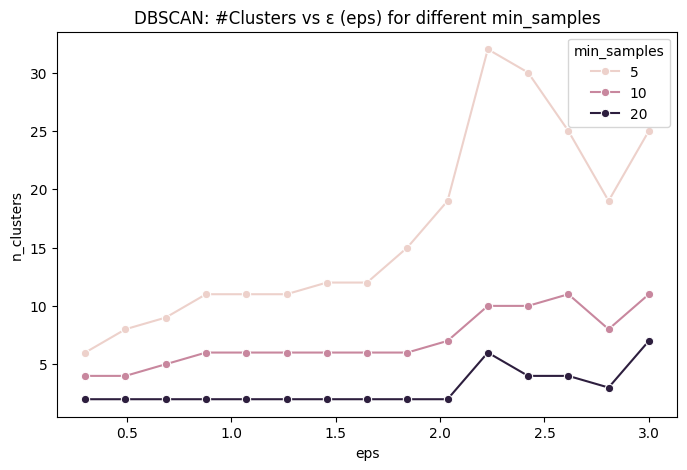

Selected DBSCAN parameters ⇒ eps=0.88, min_samples=20.0
DBSCAN found 2 clusters and 4303 noise points (-1).
Silhouette Score: 0.007


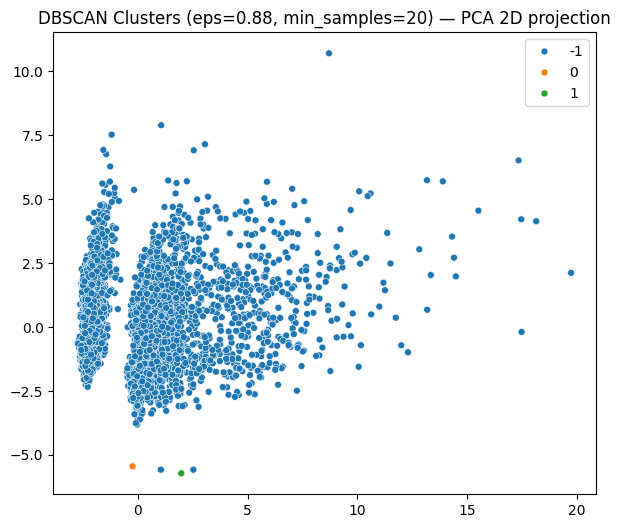

In [ ]:
# =============================================
# STEP 4 — DBSCAN Clustering (Density-Based)
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Assuming X (numeric 51-column matrix) and df_clean, df_clustered from previous steps exist

# Scale data — DBSCAN is distance-based
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Parameter sweep to study eps effect
eps_values = np.linspace(0.3, 3.0, 15)
min_samples_values = [5, 10, 20]
results = []

for eps in eps_values:
    for mins in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=mins)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        sil = None
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        results.append((eps, mins, n_clusters, n_noise, sil))

df_params = pd.DataFrame(results, columns=["eps","min_samples","n_clusters","n_noise","silhouette"])
print("\n--- DBSCAN parameter study summary (first 10) ---")
print(df_params.head(10))

plt.figure(figsize=(8,5))
sns.lineplot(data=df_params, x="eps", y="n_clusters", hue="min_samples", marker='o')
plt.title("DBSCAN: #Clusters vs ε (eps) for different min_samples")
plt.show()

# Choose best parameters (example: eps ~1.0, min_samples=10)
best_eps = df_params.query("n_clusters>1 & silhouette.notna()").sort_values("silhouette", ascending=False).head(1)
if not best_eps.empty:
    eps_opt, mins_opt = best_eps.iloc[0][["eps","min_samples"]]
else:
    eps_opt, mins_opt = 1.0, 10
print(f"Selected DBSCAN parameters ⇒ eps={eps_opt:.2f}, min_samples={mins_opt}")

# Fit DBSCAN with optimal params
db = DBSCAN(eps=eps_opt, min_samples=int(mins_opt))
labels = db.fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise points (-1).")

# Append labels
df_db = df_clean.copy()
df_db["dbscan_cluster"] = labels

# Evaluation (Silhouette only where >1 cluster)
if n_clusters > 1:
    print(f"Silhouette Score: {silhouette_score(X_scaled, labels):.3f}")

# Visualization (2D PCA)
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,6))
palette = sns.color_palette("tab10", n_colors=n_clusters+1)
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette=palette, legend="full", s=25)
plt.title(f"DBSCAN Clusters (eps={eps_opt:.2f}, min_samples={int(mins_opt)}) — PCA 2D projection")
plt.show()

# Save results
# df_db.to_csv("Unified_Features_with_DBSCAN.csv", index=False)

Matrix shape for hierarchical clustering: (4576, 51)


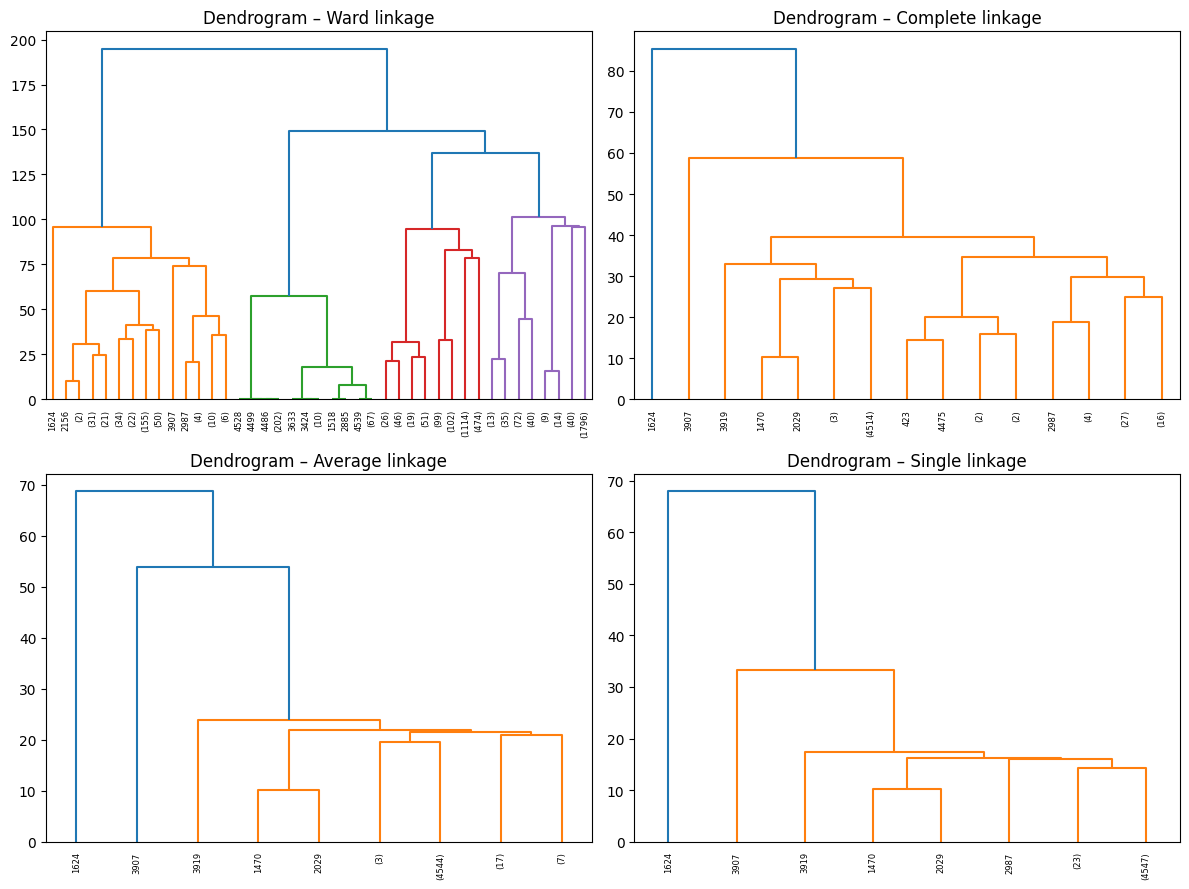

Ward       | k=4  | silhouette=0.076
Ward       | k=5  | silhouette=0.083
Ward       | k=6  | silhouette=0.087
Ward       | k=7  | silhouette=0.088
Ward       | k=8  | silhouette=0.092
Complete   | k=4  | silhouette=0.482
Complete   | k=5  | silhouette=0.453
Complete   | k=6  | silhouette=0.453
Complete   | k=7  | silhouette=0.427
Complete   | k=8  | silhouette=0.427
Average    | k=4  | silhouette=0.606
Average    | k=5  | silhouette=0.571
Average    | k=6  | silhouette=0.557
Average    | k=7  | silhouette=0.552
Average    | k=8  | silhouette=0.549
Single     | k=4  | silhouette=0.606
Single     | k=5  | silhouette=0.571
Single     | k=6  | silhouette=0.569
Single     | k=7  | silhouette=0.455
Single     | k=8  | silhouette=0.452

Hierarchical cluster label distribution:
cluster
3    1931
6    1836
1     339
2     287
4     160
5      23
Name: count, dtype: int64


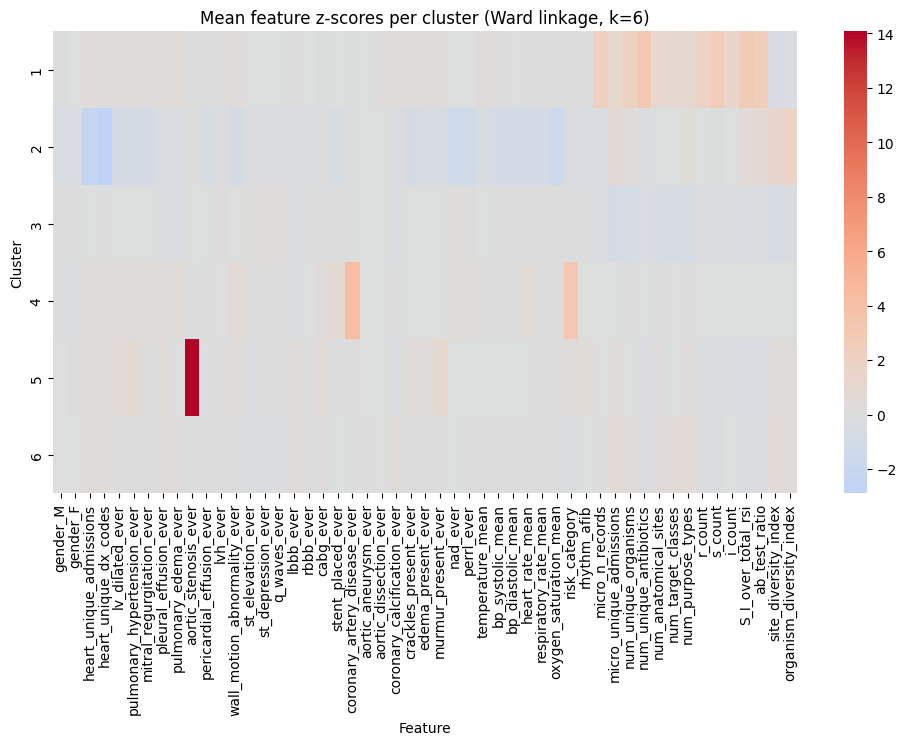


Silhouette Score (ward – k=6): 0.087


In [ ]:
# =============================================
# STEP 5 — Hierarchical Clustering
# =============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Assuming X is your numeric matrix from Step 2
print("Matrix shape for hierarchical clustering:", X.shape)

# Standardize (hierarchical methods are distance‑based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute linkages with different algorithms
link_methods = ["ward", "complete", "average", "single"]
linkages = {m: linkage(X_scaled, method=m) for m in link_methods}

# Plot dendrograms to visually compare cluster structures
plt.figure(figsize=(12, 9))
for i, method in enumerate(link_methods, 1):
    plt.subplot(2, 2, i)
    dendrogram(linkages[method],
               truncate_mode='level',  # only first few levels
               p=5,
               leaf_rotation=90.,
               leaf_font_size=6.)
    plt.title(f"Dendrogram – {method.capitalize()} linkage")
plt.tight_layout()
plt.show()

# Decide cluster count (try 5–8) and evaluate silhouette score for each linkage
for method in link_methods:
    for k in range(4, 9):
        labels = fcluster(linkages[method], k, criterion='maxclust')
        sil = silhouette_score(X_scaled, labels)
        print(f"{method.capitalize():<10} | k={k:<2d} | silhouette={sil:.3f}")

# Choose best linkage based on silhouette (usually Ward)
best_method = 'ward'
best_k = 6
labels = fcluster(linkages[best_method], best_k, criterion='maxclust')

# Attach cluster labels and visualize with heatmap
df_hier = pd.DataFrame(X_scaled, columns=X.columns)
df_hier['cluster'] = labels

print("\nHierarchical cluster label distribution:")
print(df_hier['cluster'].value_counts())

cluster_avg = df_hier.groupby('cluster').mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_avg, cmap='coolwarm', center=0)
plt.title(f"Mean feature z‑scores per cluster ({best_method.capitalize()} linkage, k={best_k})")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.show()

# Evaluate silhouette and save
sil_score = silhouette_score(X_scaled, labels)
print(f"\nSilhouette Score ({best_method} – k={best_k}): {sil_score:.3f}")

# df_hier.to_csv("Unified_Features_with_Hierarchical.csv", index=False)

Shape for outlier detection: (4576, 51)
K-Means: 2 outlier patients (distance > mean+2SD)


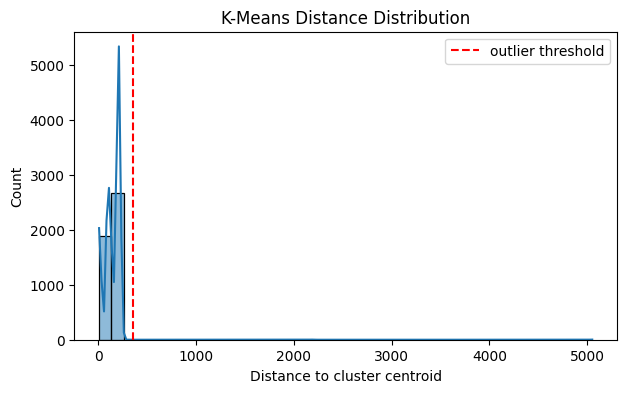

DBSCAN: 4303 noise (outlier) patients
Local Outlier Factor: 92 outlier patients (top 2%)


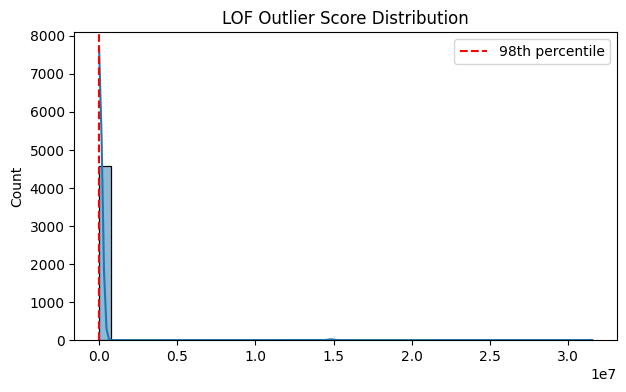

IsolationForest: 92 outlier patients (top 2%)


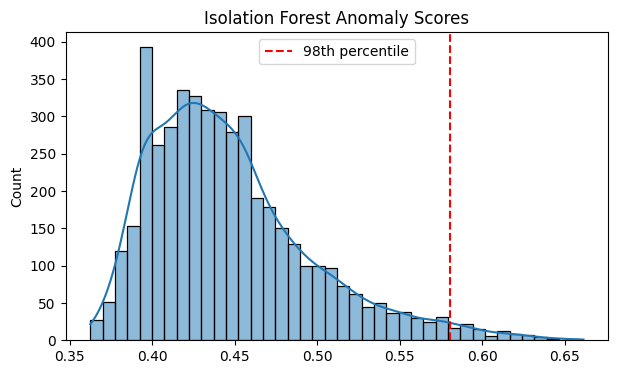


Outlier summary:
is_outlier
True     4303
False     273
Name: count, dtype: int64


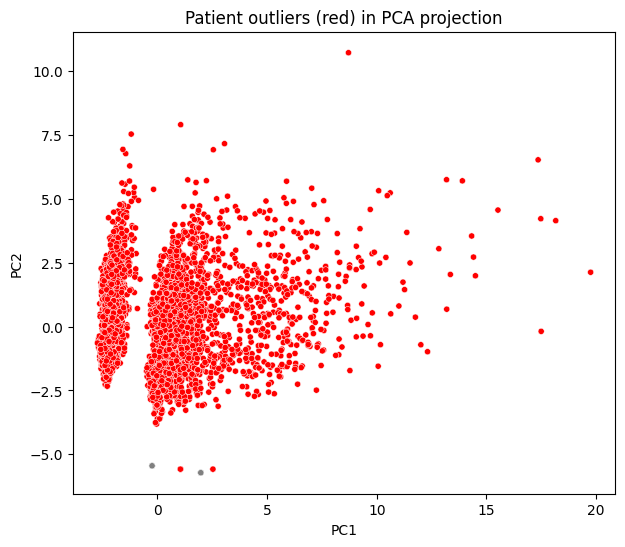

In [12]:
# =============================================
# STEP 6 — Patient-level Outlier Detection
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# X is your numeric feature matrix
print("Shape for outlier detection:", X.shape)

# Standardize the numeric variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------
# 1️⃣ Distance-based outliers from K-Means
# ---------------------------------------------------
# Reuse KMeans model from Step 3: kmeans_final and labels
distances = np.linalg.norm(X_scaled - kmeans_final.cluster_centers_[cluster_labels], axis=1)
threshold = distances.mean() + 2 * distances.std()
outliers_kmeans = np.where(distances > threshold)[0]

print(f"K-Means: {len(outliers_kmeans)} outlier patients (distance > mean+2SD)")

plt.figure(figsize=(7,4))
sns.histplot(distances, bins=40, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label='outlier threshold')
plt.title("K-Means Distance Distribution")
plt.xlabel("Distance to cluster centroid")
plt.legend()
plt.show()

# ---------------------------------------------------
# 2️⃣ Density-based outliers from DBSCAN
# ---------------------------------------------------
# Cluster label -1 already indicates outlier points
db_outliers = (df_db["dbscan_cluster"] == -1)
print(f"DBSCAN: {db_outliers.sum()} noise (outlier) patients")

# ---------------------------------------------------
# 3️⃣ Statistical detection with Local Outlier Factor
# ---------------------------------------------------
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_
lof_threshold = np.percentile(lof_scores, 98)
lof_outliers = np.where(lof_scores > lof_threshold)[0]
print(f"Local Outlier Factor: {len(lof_outliers)} outlier patients (top 2%)")

plt.figure(figsize=(7,4))
sns.histplot(lof_scores, bins=40, kde=True)
plt.axvline(lof_threshold, color='red', linestyle='--', label='98th percentile')
plt.title("LOF Outlier Score Distribution")
plt.legend()
plt.show()

# ---------------------------------------------------
# 4️⃣ Isolation Forest for robust model-independent outlier detection
# ---------------------------------------------------
iso = IsolationForest(contamination=0.02, random_state=42)
iso_labels = iso.fit_predict(X_scaled)
iso_scores = -iso.score_samples(X_scaled)
iso_threshold = np.percentile(iso_scores, 98)
iso_outliers = np.where(iso_scores > iso_threshold)[0]

print(f"IsolationForest: {len(iso_outliers)} outlier patients (top 2%)")

plt.figure(figsize=(7,4))
sns.histplot(iso_scores, bins=40, kde=True)
plt.axvline(iso_threshold, color='red', linestyle='--', label='98th percentile')
plt.title("Isolation Forest Anomaly Scores")
plt.legend()
plt.show()

# ---------------------------------------------------
# 5️⃣ Combine results from all methods
# ---------------------------------------------------
outlier_indices = set(outliers_kmeans) | set(lof_outliers) | set(iso_outliers) | set(np.where(db_outliers)[0])
outlier_mask = np.zeros(len(X), dtype=bool)
outlier_mask[list(outlier_indices)] = True

df_outliers = df_clean.copy()
df_outliers["is_outlier"] = outlier_mask
summary = df_outliers["is_outlier"].value_counts()
print("\nOutlier summary:")
print(summary)

# 6️⃣ Visualization (PCA highlighting outliers)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1],
                hue=outlier_mask, palette={True:"red", False:"grey"},
                legend=False, s=20)
plt.title("Patient outliers (red) in PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Save combined outlier flags
# df_outliers.to_csv("Unified_Features_with_Outliers.csv", index=False)

In [13]:
%pip install pyclustering

     ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
     -------- ------------------------------- 0.5/2.6 MB 5.6 MB/s eta 0:00:01
     -------------------- ------------------- 1.3/2.6 MB 4.5 MB/s eta 0:00:01
     ------------------------------------ --- 2.4/2.6 MB 4.5 MB/s eta 0:00:01
     ---------------------------------------- 2.6/2.6 MB 4.5 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395230 sha256=2949b7e52d882cb29bdf1274652b5084e5d91e674d5601400589347424da329d
  Stored in directory: c:\users\divya shah\appdata\local\pip\cache\wheels\68\29\b4\131bd7deec3663cc311ab9aa64d6517c3e3ec24b

In [14]:
# Example: CLARANS from pyclustering
from pyclustering.cluster.clarans import clarans
from sklearn.metrics import silhouette_score
import numpy as np

data = X_scaled.tolist()
clarans_instance = clarans(data, number_clusters=6, numlocal=2, maxneighbor=30)
clarans_instance.process()

clusters = clarans_instance.get_clusters()
labels = np.zeros(len(data))
for idx, cluster in enumerate(clusters):
    for i in cluster:
        labels[i] = idx

score = silhouette_score(X_scaled, labels)
print(f"CLARANS produced {len(clusters)} clusters | Silhouette = {score:.3f}")

c:\python_ins\Lib\site-packages\pyclustering\utils\__init__.py:264: SyntaxWarning: invalid escape sequence '\s'
  """!


KeyboardInterrupt: 